# Bloque 2 - Cobertura Préstec Emancipació vs precio real en Catalunya

**Pregunta:** ¿El tope de 250.000€ del Préstec cubre el precio medio real de compraventa en las provincias catalanas?

**Fuentes:**
- Precio medio de compraventa de vivienda usada por provincia catalana: Idescat / Departament de Territori, Preu mitjà de venda d'habitatges de segona mà, año 2024 (CSV descargado). Detalle adicional: precio por districte para Barcelona ciudad como zoom dentro de la provincia
- Tope Préstec: 50000€ (equivalente al 20% del valor del inmueble) entrada estática


**Año de referencia:** 2024 - Año en que se lanza el programa Préstec Emancipació

Dataset de Preu mitjà de venda d'habitatges de segona mà. Comarques i Aran, àmbits i províncies 2024

https://www.idescat.cat/indicadors/?id=aec&n=15707&t=202400-201300 

In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np

In [140]:
df_idescat = pd.read_csv("2024-idescat-aec-15707-1.csv", sep = ",",  encoding = "utf-8-sig")

print(df_idescat.shape)
df_idescat.head()

(112, 6)


,row,col,r,c,value,status
0,Alt Camp,Valor,1,1,1113.84,NaN
1,Alt Camp,Variació (%),1,2,-4.11,NaN
2,Alt Empordà,Valor,2,1,2446.70,NaN
3,Alt Empordà,Variació (%),2,2,1.44,NaN
4,Alt Penedès,Valor,3,1,1508.14,NaN


In [141]:
df_idescat.dtypes

row        object
col        object
r           int64
c           int64
value     float64
status    float64
dtype: object

## Filtro, limpieza y ordenamiento de df

Organizar el df con pivot table

In [142]:
df_idescat_pivot = (
    df_idescat[["row", "col", "value"]]
    .pivot(index = "row", columns = "col", values = "value")
    .reset_index()
    .rename(columns = {
        "row": "territorio",
        "Valor": "precio_m2_2024",
        "Variació (%)": "variacion_%_2024"
    })
)


print(df_idescat_pivot.dtypes)
df_idescat_pivot.head()

col
territorio           object
precio_m2_2024      float64
variacion_%_2024    float64
dtype: object


col,territorio,precio_m2_2024,variacion_%_2024
0,Alt Camp,1113.84,-4.11
1,Alt Empordà,2446.70,1.44
2,Alt Penedès,1508.14,-2.41
3,Alt Pirineu i Aran,2300.31,-3.17
4,Alt Urgell,1431.44,18.22


In [143]:
df_idescat_pivot.shape
print(df_idescat_pivot["territorio"].tolist())

['Alt Camp', 'Alt Empordà', 'Alt Penedès', 'Alt Pirineu i Aran', 'Alt Urgell', 'Alta Ribagorça', 'Anoia', 'Aran', 'Bages', 'Baix Camp', 'Baix Ebre', 'Baix Empordà', 'Baix Llobregat', 'Baix Penedès', 'Barcelona', 'Barcelonès', 'Berguedà', 'Camp de Tarragona', 'Catalunya', 'Cerdanya', 'Comarques Centrals', 'Comarques Gironines', 'Conca de Barberà', 'Garraf', 'Garrigues', 'Garrotxa', 'Girona', 'Gironès', 'Lleida', 'Lluçanès', 'Maresme', 'Metropolità', 'Moianès', 'Montsià', 'Noguera', 'Osona', 'Pallars Jussà', 'Pallars Sobirà', 'Penedès', "Pla d'Urgell", "Pla de l'Estany", 'Ponent', 'Priorat', "Ribera d'Ebre", 'Ripollès', 'Segarra', 'Segrià', 'Selva', 'Solsonès', 'Tarragona', 'Tarragonès', 'Terra Alta', "Terres de l'Ebre", 'Urgell', 'Vallès Occidental', 'Vallès Oriental']


Crear columna de tope_vivienda: 50000€ que equivalen al 20% del valor de la vivienda (el importe máximo del préstamo ICF)

In [144]:
tope_prestec = 50000
df_idescat_pivot["tope_vivienda"] = int(50000/0.20)
df_idescat_pivot

col,territorio,precio_m2_2024,variacion_%_2024,tope_vivienda
0,Alt Camp,1113.84,-4.11,250000
1,Alt Empordà,2446.70,1.44,250000
2,Alt Penedès,1508.14,-2.41,250000
3,Alt Pirineu i Aran,2300.31,-3.17,250000
4,Alt Urgell,1431.44,18.22,250000
5,Alta Ribagorça,1518.97,6.95,250000
6,Anoia,1428.55,7.03,250000
7,Aran,3158.56,-0.44,250000
8,Bages,1381.91,10.73,250000
9,Baix Camp,1783.64,10.02,250000


Calcular los m² que se pueden comprar, al precio medio de mercado con el presupuesto máximo del Préstec:

cálculo 250000 / precio_m2_2024

In [145]:
df_idescat_pivot["tope_m2_2024"] = (df_idescat_pivot["tope_vivienda"] / df_idescat_pivot["precio_m2_2024"]).round(2)
df_idescat_pivot

col,territorio,precio_m2_2024,variacion_%_2024,tope_vivienda,tope_m2_2024
0,Alt Camp,1113.84,-4.11,250000,224.45
1,Alt Empordà,2446.70,1.44,250000,102.18
2,Alt Penedès,1508.14,-2.41,250000,165.77
3,Alt Pirineu i Aran,2300.31,-3.17,250000,108.68
4,Alt Urgell,1431.44,18.22,250000,174.65
5,Alta Ribagorça,1518.97,6.95,250000,164.59
6,Anoia,1428.55,7.03,250000,175.00
7,Aran,3158.56,-0.44,250000,79.15
8,Bages,1381.91,10.73,250000,180.91
9,Baix Camp,1783.64,10.02,250000,140.16


Asignar nivel territorial al df

In [146]:
ambito = ["Catalunya", "Metropolità", "Comarques Gironines",
          "Camp de Tarragona", "Terres de l'Ebre", "Ponent",
          "Comarques Centrals", "Alt Pirineu i Aran", "Penedès", "Aran"]

provincias = ["Barcelona", "Girona", "Lleida", "Tarragona"]

df_idescat_pivot["nivel_territorial"] = df_idescat_pivot["territorio"].apply(
    lambda x: "ambito territorial" if x in ambito
    else "provincia" if x in provincias
    else "comarca"
)

df_idescat_pivot["nivel_territorial"].value_counts()

nivel_territorial
comarca               42
ambito territorial    10
provincia              4
Name: count, dtype: int64

## DF Provincias
Crear df de provincias a partir del nivel territorial

In [147]:
df_provincias = df_idescat_pivot[df_idescat_pivot["nivel_territorial"] == "provincia"].reset_index(drop = True)
df_provincias

col,territorio,precio_m2_2024,variacion_%_2024,tope_vivienda,tope_m2_2024,nivel_territorial
0,Barcelona,2882.05,4.43,250000,86.74,provincia
1,Girona,2284.48,1.92,250000,109.43,provincia
2,Lleida,1292.68,-2.39,250000,193.40,provincia
3,Tarragona,1634.83,5.11,250000,152.92,provincia


## DF Comarcas
Crear df de comarcas a partir del nivel territorial

In [148]:
df_comarcas = df_idescat_pivot[df_idescat_pivot["nivel_territorial"] == "comarca"].reset_index(drop = True).sort_values(by="tope_m2_2024", ascending = True)
df_comarcas

col,territorio,precio_m2_2024,variacion_%_2024,tope_vivienda,tope_m2_2024,nivel_territorial
12,Barcelonès,3827.76,5.11,250000,65.31,comarca
16,Garraf,3091.26,3.70,250000,80.87,comarca
14,Cerdanya,3018.32,-5.52,250000,82.83,comarca
10,Baix Llobregat,2824.43,2.19,250000,88.51,comarca
9,Baix Empordà,2704.09,4.61,250000,92.45,comarca
21,Maresme,2538.60,7.40,250000,98.48,comarca
1,Alt Empordà,2446.70,1.44,250000,102.18,comarca
40,Vallès Occidental,2372.22,3.50,250000,105.39,comarca
41,Vallès Oriental,2088.52,5.67,250000,119.70,comarca
35,Selva,1975.34,4.74,250000,126.56,comarca


In [149]:
comarca_provincia = {
    # Barcelona
    "Anoia": "Barcelona", "Bages": "Barcelona", "Baix Llobregat": "Barcelona",
    "Barcelonès": "Barcelona", "Berguedà": "Barcelona", "Cerdanya": "Barcelona",
    "Garraf": "Barcelona", "Lluçanès": "Barcelona", "Maresme": "Barcelona",
    "Moianès": "Barcelona", "Osona": "Barcelona", "Alt Penedès": "Barcelona",
    "Baix Penedès": "Barcelona", "Vallès Occidental": "Barcelona",
    "Vallès Oriental": "Barcelona",
    # Girona
    "Alt Empordà": "Girona", "Baix Empordà": "Girona", "Cerdanya": "Girona",
    "Garrotxa": "Girona", "Gironès": "Girona", "Pla de l'Estany": "Girona",
    "Ripollès": "Girona", "Selva": "Girona",
    # Lleida
    "Alt Urgell": "Lleida", "Alta Ribagorça": "Lleida", "Garrigues": "Lleida",
    "Noguera": "Lleida", "Pallars Jussà": "Lleida", "Pallars Sobirà": "Lleida",
    "Pla d'Urgell": "Lleida", "Segarra": "Lleida", "Segrià": "Lleida",
    "Solsonès": "Lleida", "Urgell": "Lleida",
    # Tarragona
    "Alt Camp": "Tarragona", "Baix Camp": "Tarragona", "Baix Ebre": "Tarragona",
    "Conca de Barberà": "Tarragona", "Montsià": "Tarragona", "Priorat": "Tarragona",
    "Ribera d'Ebre": "Tarragona", "Tarragonès": "Tarragona",
    "Terra Alta": "Tarragona",
}

df_comarcas["provincia"] = df_comarcas["territorio"].map(comarca_provincia)

print(df_comarcas["provincia"].isna().sum())

0


In [150]:
df_comarcas.sort_values(by= "provincia", ascending=True)

col,territorio,precio_m2_2024,variacion_%_2024,tope_vivienda,tope_m2_2024,nivel_territorial,provincia
12,Barcelonès,3827.76,5.11,250000,65.31,comarca,Barcelona
16,Garraf,3091.26,3.70,250000,80.87,comarca,Barcelona
2,Alt Penedès,1508.14,-2.41,250000,165.77,comarca,Barcelona
10,Baix Llobregat,2824.43,2.19,250000,88.51,comarca,Barcelona
6,Bages,1381.91,10.73,250000,180.91,comarca,Barcelona
21,Maresme,2538.60,7.40,250000,98.48,comarca,Barcelona
25,Osona,1547.31,0.24,250000,161.57,comarca,Barcelona
40,Vallès Occidental,2372.22,3.50,250000,105.39,comarca,Barcelona
41,Vallès Oriental,2088.52,5.67,250000,119.70,comarca,Barcelona
5,Anoia,1428.55,7.03,250000,175.00,comarca,Barcelona


## Df salario dispersión por provincia (min/max)

In [151]:
df_dispersion_b2 = df_comarcas.groupby("provincia").apply(
    lambda x: pd.Series({
        "precio_minimo": x["precio_m2_2024"].min(),
        "comarca_minimo": x.loc[x["precio_m2_2024"].idxmin(), "territorio"],
        "precio_maximo": x["precio_m2_2024"].max(),
        "comarca_maximo": x.loc[x["precio_m2_2024"].idxmax(), "territorio"]
    }),
    include_groups=False
).round(2).reset_index()

df_dispersion_b2

,provincia,precio_minimo,comarca_minimo,precio_maximo,comarca_maximo
0,Barcelona,1125.94,Lluçanès,3827.76,Barcelonès
1,Girona,1461.70,Garrotxa,3018.32,Cerdanya
2,Lleida,632.18,Garrigues,1518.97,Alta Ribagorça
3,Tarragona,774.82,Ribera d'Ebre,1868.72,Tarragonès


## INE salario promedio

In [152]:
df_salario = pd.read_csv("salario_INE.csv", sep=";", encoding="utf-8-sig")

print(df_salario.dtypes)
df_salario.head()

Comunidades y Ciudades Autónomas    object
Edad del trabajador                 object
Sexo                                object
Periodo                              int64
Total                               object
dtype: object


,Comunidades y Ciudades Autónomas,Edad del trabajador,Sexo,Periodo,Total
0,Total Nacional,Todas las edades,Ambos sexos,2024,"29.540,26"
1,Total Nacional,Todas las edades,Ambos sexos,2023,"28.049,94"
2,Total Nacional,Todas las edades,Ambos sexos,2022,"26.948,87"
3,Total Nacional,Todas las edades,Ambos sexos,2021,"25.896,82"
4,Total Nacional,Todas las edades,Ambos sexos,2020,"25.165,51"


In [153]:
df_salario["Total"] = (df_salario["Total"]
                       .str.replace('.', '', regex = False)  # eliminar punto de miles
                       .str.replace(',', '.')              # cambiar coma decimal por punto
                       .pipe(pd.to_numeric, errors = "coerce")
)

print(df_salario.dtypes)
df_salario.head()

Comunidades y Ciudades Autónomas     object
Edad del trabajador                  object
Sexo                                 object
Periodo                               int64
Total                               float64
dtype: object


,Comunidades y Ciudades Autónomas,Edad del trabajador,Sexo,Periodo,Total
0,Total Nacional,Todas las edades,Ambos sexos,2024,29540.26
1,Total Nacional,Todas las edades,Ambos sexos,2023,28049.94
2,Total Nacional,Todas las edades,Ambos sexos,2022,26948.87
3,Total Nacional,Todas las edades,Ambos sexos,2021,25896.82
4,Total Nacional,Todas las edades,Ambos sexos,2020,25165.51


In [154]:
df_salario_cataluña = df_salario[(df_salario["Comunidades y Ciudades Autónomas"] == "Cataluña") & 
                                 (df_salario["Edad del trabajador"] == "De 25 a 34 años") & 
                                 (df_salario["Periodo"] >= 2024)]


df_salario_cataluña

,Comunidades y Ciudades Autónomas,Edad del trabajador,Sexo,Periodo,Total
2856,Cataluña,De 25 a 34 años,Ambos sexos,2024,28269.97
2873,Cataluña,De 25 a 34 años,Mujeres,2024,26937.89
2890,Cataluña,De 25 a 34 años,Hombres,2024,29625.35


In [155]:
# Los salarios de Catalunya se aplican a las 4 provincias
# El INE no publica dato provincial para la EAES — se usa el agregado autonómico
sal_cat = df_salario_cataluña.set_index("Sexo")["Total"]

df_provincias["salario_H"] = sal_cat["Hombres"]
df_provincias["salario_M"] = sal_cat["Mujeres"]

df_provincias[["territorio", "precio_m2_2024", "salario_H", "salario_M"]]



col,territorio,precio_m2_2024,salario_H,salario_M
0,Barcelona,2882.05,29625.35,26937.89
1,Girona,2284.48,29625.35,26937.89
2,Lleida,1292.68,29625.35,26937.89
3,Tarragona,1634.83,29625.35,26937.89


## Análisis de capacidad financiera — Préstec Emancipació

El Préstec Emancipació cubre el 20% de la entrada (máximo 50.000€), de manera que el beneficiario debe hipotecar el 80% restante con una entidad bancaria convencional.

Para una vivienda al precio máximo elegible del programa (250.000€), la hipoteca necesaria es de 200.000€. Este análisis calcula si un joven de 25 a 34 años en Catalunya puede obtener esa financiación bancaria con su salario medio.

**Supuestos del modelo** (idénticos al Bloque 1 para comparabilidad):
- Salario bruto → neto: factor 0,78 (SS 6,35% + IRPF efectivo ~15,5%)
- Tasa de esfuerzo máxima: 35% de los ingresos netos mensuales (Banco de España)
- Tipo hipotecario: 3,25% fijo (INE, Estadística de Hipotecas, media anual 2024)
- Plazo: 25 años (INE, plazo medio 2024)
- Financiación bancaria: 80% del precio de la vivienda

**Nota metodológica:** El INE no publica datos salariales por provincia en la
Encuesta Anual de Estructura Salarial. Se utiliza el salario medio de Catalunya
como aproximación para las cuatro provincias.

In [156]:
# Parámetros del modelo
factor_neto = 0.78        # bruto → neto (SS 6,35% + IRPF efectivo ~15,5%)
tasa_esfuerzo = 0.35      # recomendación Banco de España
tipo_hipotecario = 0.0325 # INE Estadística Hipotecas 2024
plazo_meses = 25 * 12     # 300 meses
financiacion_banco = 0.80 # el banco financia el 80%
r = tipo_hipotecario / 12

hipoteca_necesaria = 250000 * financiacion_banco  # 200.000€

### Capacidad financiera — Mujeres

In [157]:
df_provincias["sal_neto_mensual_M"] = (df_provincias["salario_M"] * factor_neto / 12).round(2)
df_provincias["cuota_max_M"] = (df_provincias["sal_neto_mensual_M"] * tasa_esfuerzo).round(2)
df_provincias["hipoteca_max_M"] = (df_provincias["cuota_max_M"] * (1 - (1 + r)**-plazo_meses) / r).round(2)
df_provincias["brecha_acceso_M"] = (df_provincias["hipoteca_max_M"] - hipoteca_necesaria).round(2)

df_provincias[["territorio", "hipoteca_max_M", "brecha_acceso_M"]]

col,territorio,hipoteca_max_M,brecha_acceso_M
0,Barcelona,125758.18,-74241.82
1,Girona,125758.18,-74241.82
2,Lleida,125758.18,-74241.82
3,Tarragona,125758.18,-74241.82


### Capacidad financiera — Hombres

In [158]:
df_provincias["sal_neto_mensual_H"] = (df_provincias["salario_H"] * factor_neto / 12).round(2)
df_provincias["cuota_max_H"] = (df_provincias["sal_neto_mensual_H"] * tasa_esfuerzo).round(2)
df_provincias["hipoteca_max_H"] = (df_provincias["cuota_max_H"] * (1 - (1 + r)**-plazo_meses) / r).round(2)
df_provincias["brecha_acceso_H"] = (df_provincias["hipoteca_max_H"] - hipoteca_necesaria).round(2)

df_provincias[["territorio", "hipoteca_max_H", "brecha_acceso_H"]]

col,territorio,hipoteca_max_H,brecha_acceso_H
0,Barcelona,138304.44,-61695.56
1,Girona,138304.44,-61695.56
2,Lleida,138304.44,-61695.56
3,Tarragona,138304.44,-61695.56


### Capacidad financiera — Parejas

Se modelan tres escenarios de unidad familiar con dos solicitantes, asumiendo que ambas personas trabajan y perciben el salario medio de Catalunya para el tramo de 25 a 34 años.

**Supuesto:** ambos solicitantes trabajan a jornada completa y perciben el salario medio de Catalunya. No se modela situación de desempleo, trabajo parcial ni diferencial salarial por sector.

**Restricción del programa:** el Préstec Emancipació establece que los ingresos brutos anuales de todos los miembros de la unidad de convivencia no pueden superar el IRSC × 6,5. Para dos personas el límite es 85.971,60€ conjuntos. Los salarios medios del tramo 25-34 años están por debajo de este límite en todos los escenarios modelados.

**Escenarios:**
- Pareja HM: hombre + mujer (salario medio H + salario medio M)
- Pareja MM: dos mujeres (salario medio M × 2)
- Pareja HH: dos hombres (salario medio H × 2)

In [159]:
df_provincias["salario_pareja_HM"] = df_provincias["salario_H"] + df_provincias["salario_M"]
df_provincias["salario_pareja_MM"] = df_provincias["salario_M"] * 2
df_provincias["salario_pareja_HH"] = df_provincias["salario_H"] * 2

for sufijo, col_sal in [("pareja_HM", "salario_pareja_HM"), ("pareja_MM", "salario_pareja_MM"), ("pareja_HH", "salario_pareja_HH")]:
    df_provincias[f"sal_neto_mensual_{sufijo}"] = (df_provincias[col_sal] * factor_neto / 12).round(2)
    df_provincias[f"cuota_max_{sufijo}"] = (df_provincias[f"sal_neto_mensual_{sufijo}"] * tasa_esfuerzo).round(2)
    df_provincias[f"hipoteca_max_{sufijo}"] = (df_provincias[f"cuota_max_{sufijo}"] * (1 - (1 + r)**-plazo_meses) / r).round(2)
    df_provincias[f"brecha_acceso_{sufijo}"] = (df_provincias[f"hipoteca_max_{sufijo}"] - hipoteca_necesaria).round(2)

df_provincias[["territorio", "brecha_acceso_pareja_HM", "brecha_acceso_pareja_MM", "brecha_acceso_pareja_HH"]]

col,territorio,brecha_acceso_pareja_HM,brecha_acceso_pareja_MM,brecha_acceso_pareja_HH
0,Barcelona,64060.57,51516.35,76608.89
1,Girona,64060.57,51516.35,76608.89
2,Lleida,64060.57,51516.35,76608.89
3,Tarragona,64060.57,51516.35,76608.89


### Tres brechas de acceso comparativa (mujeres, hombres y parejas)

In [160]:
df_provincias[["territorio", "brecha_acceso_H", "brecha_acceso_M", "brecha_acceso_pareja_HM", "brecha_acceso_pareja_MM", "brecha_acceso_pareja_HH"]]

col,territorio,brecha_acceso_H,brecha_acceso_M,brecha_acceso_pareja_HM,brecha_acceso_pareja_MM,brecha_acceso_pareja_HH
0,Barcelona,-61695.56,-74241.82,64060.57,51516.35,76608.89
1,Girona,-61695.56,-74241.82,64060.57,51516.35,76608.89
2,Lleida,-61695.56,-74241.82,64060.57,51516.35,76608.89
3,Tarragona,-61695.56,-74241.82,64060.57,51516.35,76608.89


### Brecha de acceso: m² financiables por perfil

La brecha de acceso se expresa en metros cuadrados financiables al precio medio provincial de 2024.
Para cada perfil se calcula cuántos m² puede financiar la hipoteca máxima que permite su salario,
y se compara con los m² equivalentes al tope del programa (250.000€ / precio_m2_2024).

Una brecha negativa indica que el perfil no puede financiar una vivienda al precio del tope del
programa: le faltan esos m² para llegar al umbral de elegibilidad del Préstec Emancipació.

Esta métrica varía por provincia porque el precio por m² es diferente en cada una, lo que
permite identificar dónde la barrera de acceso es mayor.

In [161]:
perfiles = {
    "H": "hipoteca_max_H",
    "M": "hipoteca_max_M",
    "pareja_HM": "hipoteca_max_pareja_HM",
    "pareja_MM": "hipoteca_max_pareja_MM",
    "pareja_HH": "hipoteca_max_pareja_HH"
}

for perfil, col_hipoteca in perfiles.items():
    df_provincias[f"m2_financiables_{perfil}"] = (
        df_provincias[col_hipoteca] / df_provincias["precio_m2_2024"]
    ).round(1)
    df_provincias[f"brecha_m2_{perfil}"] = (
        df_provincias[f"m2_financiables_{perfil}"] - df_provincias["tope_m2_2024"]
    ).round(1)

cols_resultado = (
    ["territorio", "precio_m2_2024", "tope_m2_2024"]
    + [f"m2_financiables_{p}" for p in perfiles]
    + [f"brecha_m2_{p}" for p in perfiles]
)

df_provincias[cols_resultado]

col,territorio,precio_m2_2024,tope_m2_2024,m2_financiables_H,m2_financiables_M,m2_financiables_pareja_HM,m2_financiables_pareja_MM,m2_financiables_pareja_HH,brecha_m2_H,brecha_m2_M,brecha_m2_pareja_HM,brecha_m2_pareja_MM,brecha_m2_pareja_HH
0,Barcelona,2882.05,86.74,48.0,43.6,91.6,87.3,96.0,-38.7,-43.1,4.9,0.6,9.3
1,Girona,2284.48,109.43,60.5,55.0,115.6,110.1,121.1,-48.9,-54.4,6.2,0.7,11.7
2,Lleida,1292.68,193.40,107.0,97.3,204.3,194.6,214.0,-86.4,-96.1,10.9,1.2,20.6
3,Tarragona,1634.83,152.92,84.6,76.9,161.5,153.8,169.2,-68.3,-76.0,8.6,0.9,16.3


## Visualización 1 — Capacidad financiera por perfil de hogar

Hipoteca máxima financiable según salario medio de Catalunya (tramo 25-34 años, 2024)
para cada configuración de hogar. La línea roja marca los 200.000€ necesarios para
financiar el 80% de una vivienda al tope máximo del Préstec Emancipació (250.000€).

In [162]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns

# Paleta semántica del proyecto (igual que Bloque 1): un color = un concepto.
HOMBRE      = "#2C6FB0"
MUJER       = "#E07B39"
PAREJA_HM   = "#7E4DA0"
PAREJA_MM   = "#D6457F"
PAREJA_HH   = "#17A2B8"
CUBIERTO    = "#2E9E5B"
NO_CUBIERTO = "#D64545"
MERCADO     = "#5A5A66"
TOPE_ICO    = "#E6A700"
SIN_DATO    = "#B8BCC4"
CONJUNTO    = "#8C6D46"
TEXT = "#222222"
GRID = "#D9D9D9"

# Identidad por provincia: gradiente azul-pizarra ordenado por precio (oscuro = más caro).
PROV = {
    "Barcelona": "#16404D",
    "Girona":    "#2E6E80",
    "Tarragona": "#6BA3B5",
    "Lleida":    "#A9C5D1",
}

sns.set_theme(style="white")
plt.rcParams["axes.facecolor"]   = "white"
plt.rcParams["figure.facecolor"] = "white"


def apply_light_style(ax, fig, grid_axis="both"):
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(TEXT)
    ax.spines[["top", "right"]].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_edgecolor(GRID)
    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.6, linestyle="--", alpha=0.8)
    ax.set_axisbelow(True)


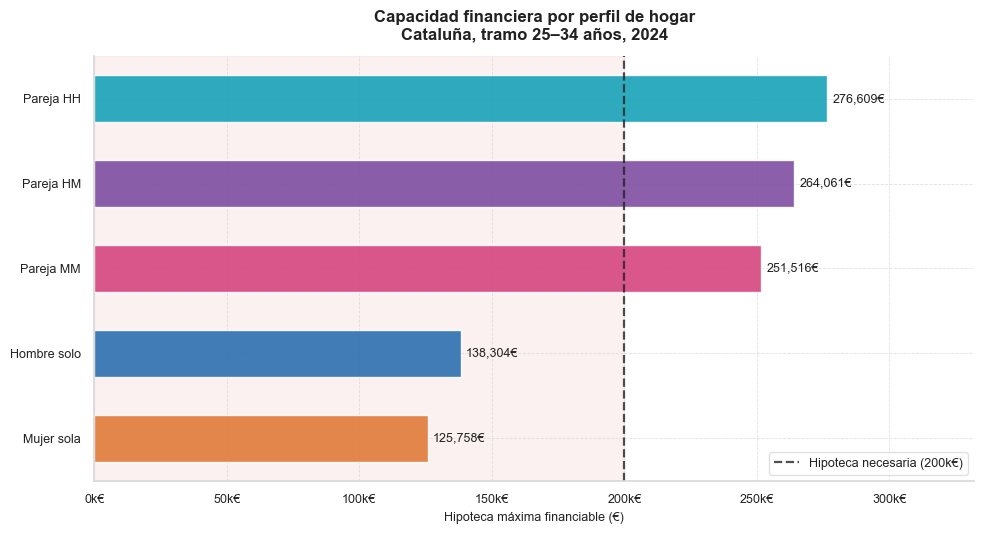

In [163]:
perfiles    = ["M", "H", "pareja_MM", "pareja_HM", "pareja_HH"]
etiquetas   = ["Mujer sola", "Hombre solo", "Pareja MM", "Pareja HM", "Pareja HH"]
colores_bar = [MUJER, HOMBRE, PAREJA_MM, PAREJA_HM, PAREJA_HH]

valores = [df_provincias.loc[0, f"hipoteca_max_{p}"] for p in perfiles]

fig, ax = plt.subplots(figsize=(10, 5.5))
apply_light_style(ax, fig)

bars = ax.barh(etiquetas, valores, color=colores_bar, height=0.55, alpha=0.9)

ax.axvline(x=hipoteca_necesaria, color=TEXT, linewidth=1.6, linestyle="--",
           label=f"Hipoteca necesaria ({int(hipoteca_necesaria/1000)}k€)", alpha=0.8)
ax.axvspan(0, hipoteca_necesaria, alpha=0.07, color=NO_CUBIERTO, zorder=0)

for bar, v in zip(bars, valores):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height() / 2,
            f"{v:,.0f}€", va="center", fontsize=9, color=TEXT)

ax.set_xlabel("Hipoteca máxima financiable (€)", fontsize=9)
ax.set_title("Capacidad financiera por perfil de hogar\nCataluña, tramo 25–34 años, 2024",
             fontsize=12, fontweight="bold", pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k€"))
ax.set_xlim(0, max(valores) * 1.20)

ax.legend(fontsize=9, facecolor="white", edgecolor=GRID, labelcolor=TEXT)

plt.tight_layout()
plt.savefig("b2_barras_capacidad_financiera_v2.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


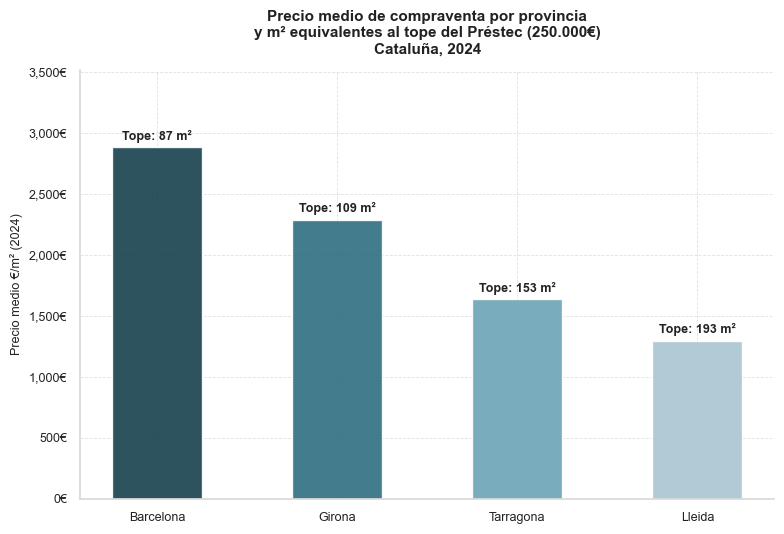

In [164]:
df_prov_ord   = df_provincias.sort_values("precio_m2_2024", ascending=False)
provincias_b2 = df_prov_ord["territorio"].tolist()
precios_b2    = df_prov_ord["precio_m2_2024"].tolist()
tope_m2_b2    = df_prov_ord["tope_m2_2024"].tolist()
colores_b2    = [PROV[p] for p in provincias_b2]

fig, ax = plt.subplots(figsize=(8, 5.5))
apply_light_style(ax, fig)

bars = ax.bar(provincias_b2, precios_b2, color=colores_b2, width=0.5, alpha=0.9)

for bar, m2 in zip(bars, tope_m2_b2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
            f"Tope: {m2:.0f} m²", ha="center", va="bottom",
            fontsize=9, color=TEXT, fontweight="bold")

ax.set_ylabel("Precio medio €/m² (2024)", fontsize=9)
ax.set_title("Precio medio de compraventa por provincia\ny m² equivalentes al tope del Préstec (250.000€)\nCataluña, 2024",
             fontsize=11, fontweight="bold", pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}€"))
ax.set_ylim(0, max(precios_b2) * 1.22)

plt.tight_layout()
plt.savefig("b2_barras_precio_m2_provincias_v2.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


### Zoom por comarca: m² que compra el tope

El promedio provincial esconde fuertes diferencias internas. Con el mismo tope (250.000€) se compran muchos más m² en la comarca más barata que en la más cara de cada provincia (Barcelona: Lluçanès vs Barcelonès; Girona: Garrotxa vs Cerdanya). La línea discontinua marca la media provincial: pese a ser la provincia más barata, **Lleida es donde el tope alcanza más m²**.

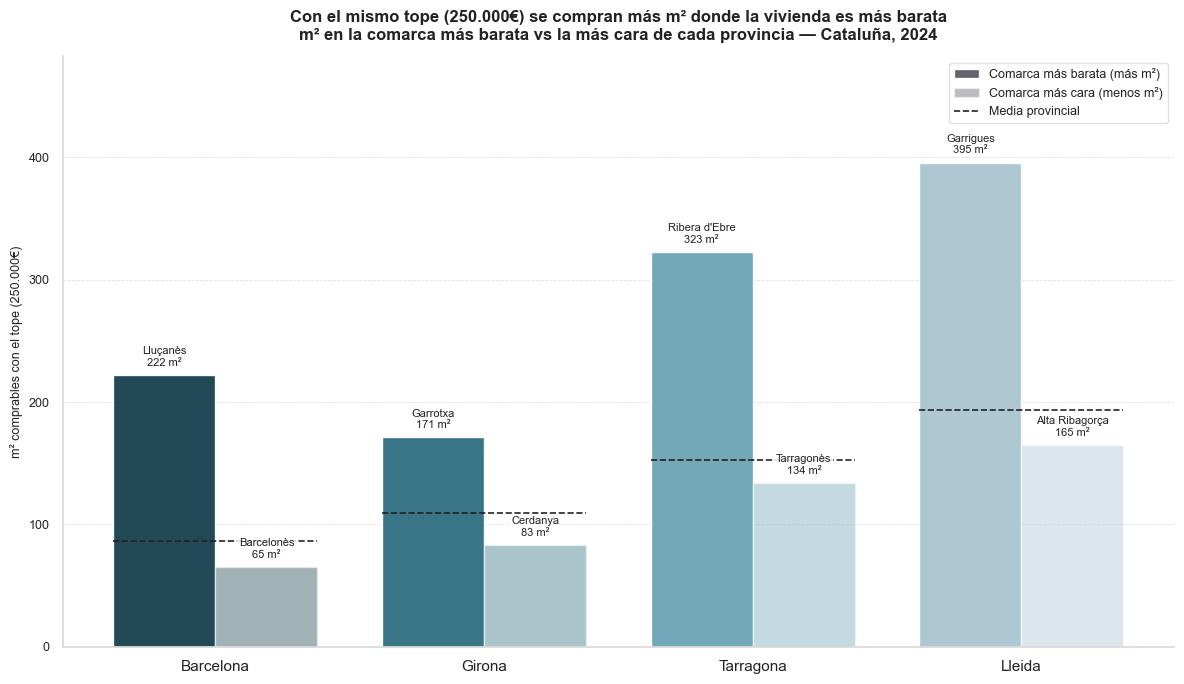

In [167]:
prov_orden = df_provincias.sort_values("precio_m2_2024", ascending=False)["territorio"].tolist()
tope = df_provincias["tope_vivienda"].iloc[0]
disp = df_dispersion_b2.set_index("provincia")

x = np.arange(len(prov_orden))
w = 0.38
bbox_label = dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85)

m2_mas   = [tope / disp.loc[p, "precio_minimo"] for p in prov_orden]
m2_menos = [tope / disp.loc[p, "precio_maximo"] for p in prov_orden]
nom_mas   = [disp.loc[p, "comarca_minimo"] for p in prov_orden]
nom_menos = [disp.loc[p, "comarca_maximo"] for p in prov_orden]
m2_media = [df_provincias.loc[df_provincias["territorio"] == p, "tope_m2_2024"].values[0] for p in prov_orden]

fig, ax = plt.subplots(figsize=(12, 7))
apply_light_style(ax, fig, grid_axis="y")

for i, p in enumerate(prov_orden):
    c = PROV[p]
    ax.bar(i - w / 2, m2_mas[i],   width=w, color=c, alpha=0.95, zorder=2)
    ax.bar(i + w / 2, m2_menos[i], width=w, color=c, alpha=0.40, zorder=2)
    ax.hlines(m2_media[i], i - w, i + w, color=TEXT, linestyle="--", linewidth=1.2, zorder=3)
    ax.text(i - w / 2, m2_mas[i] + 6,   f"{nom_mas[i]}\n{m2_mas[i]:.0f} m²",
            ha="center", va="bottom", fontsize=8, color=TEXT, zorder=5, bbox=bbox_label)
    ax.text(i + w / 2, m2_menos[i] + 6, f"{nom_menos[i]}\n{m2_menos[i]:.0f} m²",
            ha="center", va="bottom", fontsize=8, color=TEXT, zorder=5, bbox=bbox_label)

ax.set_xticks(x)
ax.set_xticklabels(prov_orden, fontsize=11)
ax.set_ylabel("m² comprables con el tope (250.000€)", fontsize=9)
ax.set_ylim(0, max(m2_mas) * 1.22)
ax.set_title("Con el mismo tope (250.000€) se compran más m² donde la vivienda es más barata\n"
             "m² en la comarca más barata vs la más cara de cada provincia — Cataluña, 2024",
             fontsize=12, fontweight="bold", pad=12)

leyenda = [
    mpatches.Patch(facecolor=MERCADO, alpha=0.95, label="Comarca más barata (más m²)"),
    mpatches.Patch(facecolor=MERCADO, alpha=0.40, label="Comarca más cara (menos m²)"),
    mlines.Line2D([0], [0], color=TEXT, linestyle="--", linewidth=1.2, label="Media provincial"),
]
ax.legend(handles=leyenda, fontsize=9, facecolor="white", edgecolor=GRID, labelcolor=TEXT, loc="upper right")

plt.tight_layout()
plt.savefig("b2_barras_m2_comarca_extremos_v2.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


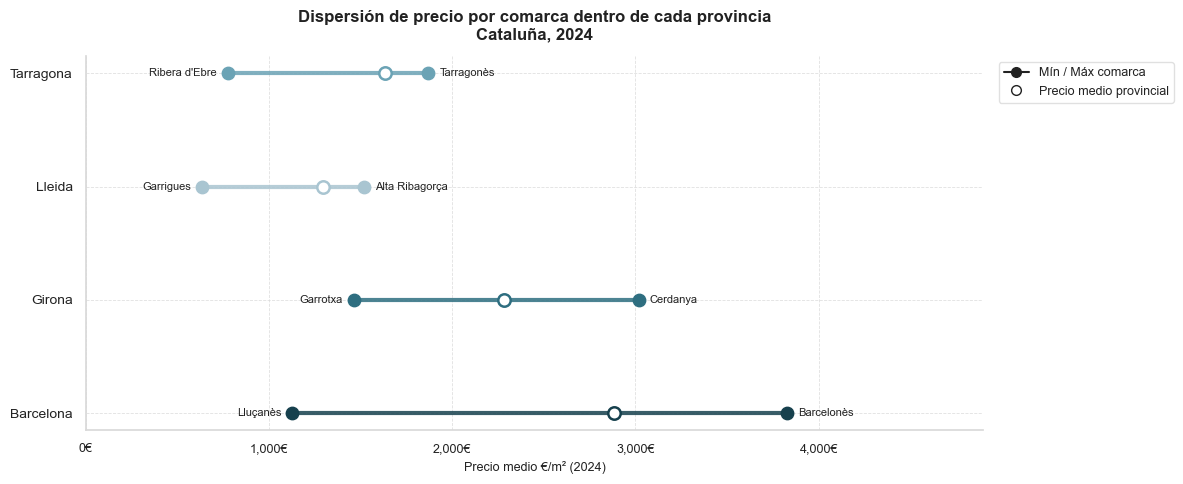

In [166]:
fig, ax = plt.subplots(figsize=(12, 5))
apply_light_style(ax, fig)

for i, row in df_dispersion_b2.iterrows():
    provincia  = row["provincia"]
    precio_min = row["precio_minimo"]
    precio_max = row["precio_maximo"]
    precio_med = df_provincias.loc[df_provincias["territorio"] == provincia, "precio_m2_2024"].values[0]
    color = PROV[provincia]

    ax.plot([precio_min, precio_max], [i, i], color=color, linewidth=3, zorder=2, alpha=0.85)
    ax.scatter(precio_min, i, color=color, s=80, zorder=3)
    ax.scatter(precio_max, i, color=color, s=80, zorder=3)
    ax.scatter(precio_med, i, facecolors="white", edgecolors=color, s=80, linewidth=1.8, zorder=4)

    ax.text(precio_min - 60, i, row["comarca_minimo"], ha="right", va="center", fontsize=8, color=TEXT)
    ax.text(precio_max + 60, i, row["comarca_maximo"], ha="left", va="center", fontsize=8, color=TEXT)

ax.set_yticks(range(len(df_dispersion_b2)))
ax.set_yticklabels(df_dispersion_b2["provincia"].tolist(), fontsize=10)
ax.set_xlabel("Precio medio €/m² (2024)", fontsize=9)
ax.set_title("Dispersión de precio por comarca dentro de cada provincia\nCataluña, 2024",
             fontsize=12, fontweight="bold", pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}€"))
ax.set_xlim(0, df_dispersion_b2["precio_maximo"].max() * 1.28)

leyenda = [
    mlines.Line2D([0], [0], marker="o", color=TEXT, markersize=7,
                  label="Mín / Máx comarca", linestyle="-"),
    mlines.Line2D([0], [0], marker="o", color=TEXT, markerfacecolor="white",
                  markersize=7, label="Precio medio provincial", linestyle="None"),
]
ax.legend(handles=leyenda, fontsize=9, facecolor="white", edgecolor=GRID,
          labelcolor=TEXT, bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.savefig("b2_rangeplot_comarcas_v2.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
